# FASE 0: Preparación y Recolección del Corpus

## Análisis de sentimientos en respuestas abiertas de estudiantes

**Autor:** Jaime Meléndez Zambrano

**Proyecto guía de referencia:** este proyecto sigue la estructura de la asignación
*"Laboratorio NLP: Aprendizaje Supervisado, No Supervisado y Generativo"*, usando
como orientación un proyecto ya resuelto por otra compañera sobre el mismo tipo de
datos ([PROYECTO_NLP_ESTUDIANTE](https://github.com/18paz/PROYECTO_NLP_ESTUDIANTE)),
pero construido de forma propia y con una clasificación de sentimientos en
**3 categorías** en lugar de 2.

El corpus utilizado proviene de respuestas abiertas de estudiantes a una encuesta
sobre dos temas:

1. ¿Cómo te sientes respecto al tiempo que pasas en la escuela y el tiempo libre que
   te queda en casa?
2. ¿Qué opinión tienes sobre el volumen de tareas, proyectos y evaluaciones
   académicas que recibes?

La encuesta fue aplicada por **12 compañeros encuestadores** (cada quien a su propio
grupo de estudiantes) y las respuestas crudas de los 12 se recopilaron en
`data/bases_de_datos/`. Esta versión del proyecto reconstruye el corpus a partir de
**todas** esas respuestas (965 respuestas individuales), en vez de usar solo la
submuestra de un encuestador que usaba la versión anterior de este proyecto (199
respuestas, todas de un mismo encuestador). Ver la sección "Consolidación de las 12
fuentes" más abajo para el detalle de por qué eso importa y cómo se hizo.

---

## Plan de Corpus

```
─────────────────────────────────────────────────────────────
               PLAN DE CORPUS
─────────────────────────────────────────────────────────────

INTEGRANTES: Jaime Meléndez Zambrano

TEMA ELEGIDO: Análisis de sentimientos en respuestas abiertas de estudiantes
              sobre el tiempo escolar, el tiempo libre y la carga académica.

CATEGORÍAS PROPUESTAS:
1. Sentimientos placenteros     (bienestar, calma, satisfacción)
2. Sentimientos desagradables   (cansancio, estrés, ansiedad, presión)
3. Sentimientos mixtos          (respuestas con evidencia positiva Y negativa
                                  a la vez, típicamente unidas por "pero")

FUENTES DE DATOS:
- ¿De dónde obtendrán los textos?
  De una encuesta recolectada por 12 compañeros encuestadores, cada uno con su
  propio grupo de estudiantes (archivos .txt crudos en `data/bases_de_datos/`,
  organizados en 12 carpetas `encuesta_<nombre>/`). En total, 965 respuestas
  individuales a las 2 preguntas abiertas.

- ¿Cómo garantizarán la calidad?
  Cada uno de los 12 encuestadores guardó sus datos en un formato distinto
  (ver más abajo). Se identificaron los 5 formatos, se validó cada uno contra
  el 100% de sus archivos (no una muestra) y se normalizaron a un esquema
  único: encuestador, archivo de origen, pregunta de origen, texto. Luego se
  verificó codificación UTF-8, longitudes, y se revisaron duplicados y casos
  ambiguos. Ver la sección "Calidad y validación del corpus" más abajo.

ETIQUETADO:
- ¿Quién etiquetará los textos?
  Dado que el archivo original no trae una etiqueta de sentimiento, se diseñó
  un etiquetador semi-automático basado en un diccionario (lexicón) de
  palabras y frases en español asociadas a sentimientos placenteros y
  desagradables, más la detección de conectores de contraste ("pero",
  "aunque") para identificar sentimientos mixtos. La lógica completa está en
  `src/etiquetador_sentimientos.py` y es 100% auditable (cada etiqueta queda
  con la evidencia -palabras/frases- que la sustenta).

- ¿Cómo manejarán textos dudosos o ambiguos?
  Cuando el texto tiene evidencia positiva Y negativa a la vez, se etiqueta
  directamente como "mixto" (en vez de forzarlo a una sola polaridad). Los
  textos sin ninguna evidencia léxica quedan marcados como
  "revisar_manualmente" para inspección humana y se excluyen del corpus de
  entrenamiento (quedan aparte, no se descartan). Con el corpus ampliado a 12
  encuestadores esto ya no es un caso hipotético: el 11% de los textos cae en
  esta categoría (ver más abajo).

FECHA LÍMITE: Según cronograma del curso (4-6 semanas)
─────────────────────────────────────────────────────────────
```

### Nota metodológica sobre la longitud mínima de los textos

La guía de la tarea sugiere un mínimo de 100 palabras por texto, pensado para
corpus de textos literarios (cuentos, poesías, fábulas). Nuestro corpus es de
**respuestas abiertas de encuesta** (más parecido a la categoría sugerida de
"Redes sociales" o "Reseñas de productos" que a "Géneros literarios"): son
respuestas cortas y directas. Se decidió mantener cada respuesta como un texto
individual (en vez de fusionar varias respuestas en documentos artificiales de
100+ palabras) porque:

- Es la unidad de análisis real y honesta de los datos (una respuesta = una
  opinión de un estudiante).
- Se compensa la brevedad con una **cantidad de textos muy superior al
  mínimo exigido** (965 textos crudos, 843 en el corpus de entrenamiento,
  frente al mínimo de 30).
- Es más útil para los clasificadores de la Fase 2 tener más ejemplos
  (aunque cortos) que menos ejemplos artificialmente largos.

## Importar librerías

In [1]:
import os
import sys
import pandas as pd

sys.path.insert(0, os.path.abspath('../src'))

## Consolidación de las 12 fuentes crudas

`data/bases_de_datos/` contiene 830 archivos `.txt`, uno por respuesta o por
estudiante según el encuestador, repartidos en 12 carpetas `encuesta_<nombre>/`.
Al inspeccionar los 12 formatos (no solo una muestra: se validó el 100% de los
archivos de cada carpeta) se encontraron **5 convenciones distintas**:

| Formato | Encuestadores | Descripción |
|:---|:---|:---|
| A | abraham, edgar, elvis, jair, juan, karen, menco | 1 archivo = 1 respuesta; el número de pregunta va en el nombre del archivo |
| B | eberto, jaime | 1 archivo = 2 respuestas, como 2 oraciones seguidas sin salto de línea |
| C | marlon | 1 archivo = 2 respuestas, separadas por una línea en blanco |
| D | jorge | 1 archivo = 1 respuesta general que mezcla ambos temas, sin separación clara |
| E | rosaura | 1 archivo = 1 línea CSV `indice;codigo;respuesta1;respuesta2` |

La versión anterior de este proyecto solo usaba los datos de **un** encuestador
(menco, 200 archivos ⇒ 199 respuestas tras un error de construcción del corpus:
dos respuestas quedaron fusionadas en una sola celda de un Excel por un salto de
línea faltante). Esta versión reconstruye el corpus leyendo **directamente** los
`.txt` crudos de los 12 encuestadores (`src/construir_corpus.py`), lo que de paso
elimina ese tipo de error: ya no depende de un Excel intermedio frágil.

In [2]:
from construir_corpus import cargar_respuestas_individuales

df_raw = cargar_respuestas_individuales()
print("Total de respuestas individuales:", len(df_raw))
df_raw.head()


Total de respuestas individuales: 965


,id,encuestador,archivo_origen,pregunta_num,pregunta_origen,texto,num_palabras
0,texto_0000,abraham,pregunta1_estudiante001.txt,1,¿Cómo te sientes respecto al tiempo que pasas ...,bueno en la escuela me la paso bien y me rio m...,30
1,texto_0001,abraham,pregunta1_estudiante002.txt,1,¿Cómo te sientes respecto al tiempo que pasas ...,aquí en el colegio me la paso super bien compa...,33
2,texto_0002,abraham,pregunta1_estudiante003.txt,1,¿Cómo te sientes respecto al tiempo que pasas ...,me siento más cómodo en el colegio porque me d...,31
3,texto_0003,abraham,pregunta1_estudiante004.txt,1,¿Cómo te sientes respecto al tiempo que pasas ...,cuando estoy en el colegio me quiero ir a mi c...,28
4,texto_0004,abraham,pregunta1_estudiante005.txt,1,¿Cómo te sientes respecto al tiempo que pasas ...,"a veces con pereza y sueño en el colegio, en m...",27


In [3]:
print("Respuestas por encuestador:")
print(df_raw['encuestador'].value_counts())
print()
print("Respuestas por pregunta de origen:")
print(df_raw['pregunta_num'].value_counts())
print()
print(df_raw['num_palabras'].describe())


Respuestas por encuestador:
encuestador
menco      200
jorge       99
eberto      80
elvis       80
marlon      70
abraham     68
edgar       64
jair        62
karen       62
jaime       60
juan        60
rosaura     60
Name: count, dtype: int64

Respuestas por pregunta de origen:
pregunta_num
2          435
1          431
general     99
Name: count, dtype: int64

count    965.000000
mean      17.346114
std       13.532901
min        1.000000
25%       11.000000
50%       14.000000
75%       19.000000
max      211.000000
Name: num_palabras, dtype: float64


## Etiquetado semi-automático de sentimientos

Se aplica el etiquetador basado en diccionario (`src/etiquetador_sentimientos.py`).
Cada respuesta recibe una etiqueta (`placentero`, `desagradable`, `mixto` o
`revisar_manualmente`) junto con la evidencia léxica que sustenta la decisión, para
que el proceso sea transparente y verificable.

In [4]:
from etiquetador_sentimientos import etiquetar

ejemplos = df_raw['texto'].head(5).apply(etiquetar)
for texto, res in zip(df_raw['texto'].head(5), ejemplos):
    print(f"TEXTO: {texto[:90]}...")
    print(f"  -> {res['etiqueta']}  (pos={res['pos_score']}, neg={res['neg_score']})")
    print(f"     evidencia positiva: {res['evidencia_pos']}")
    print(f"     evidencia negativa: {res['evidencia_neg']}")
    print()


TEXTO: bueno en la escuela me la paso bien y me rio mucho con mis compañeros, pero en mi casa me ...
  -> placentero  (pos=2, neg=0)
     evidencia positiva: ['bien', 'gusta']
     evidencia negativa: []

TEXTO: aquí en el colegio me la paso super bien comparto mucho con mis amigos, aunque a veces sal...
  -> mixto  (pos=1, neg=5)
     evidencia positiva: ['bien']
     evidencia negativa: ['no me queda', 'casi no me', 'cansado']

TEXTO: me siento más cómodo en el colegio porque me distraigo con mis amigos, pero al llegar a ca...
  -> mixto  (pos=1, neg=1)
     evidencia positiva: ['cómodo']
     evidencia negativa: ['poco']

TEXTO: cuando estoy en el colegio me quiero ir a mi casa pero cuando estoy allá me aburro, me gus...
  -> mixto  (pos=1, neg=2)
     evidencia positiva: ['gusta']
     evidencia negativa: ['aburro', 'agotador']

TEXTO: a veces con pereza y sueño en el colegio, en mi casa me siento un poco más activo pero la ...
  -> mixto  (pos=1, neg=1)
     evidencia positiva: ['

### Calibración del lexicón contra el corpus completo

El lexicón original se había calibrado únicamente contra los 199 textos de un solo
encuestador ("hasta que ningún texto quedara sin evidencia léxica", según la
documentación original). Al aplicarlo tal cual a los 965 textos de los 12
encuestadores —con 12 estilos de escritura y modismos regionales distintos
("chévere", "bacano", "flojera", etc.)— el **27%** de los textos quedaba sin poder
etiquetarse (`revisar_manualmente`).

Se recalibró el lexicón en dos iteraciones, cada una con el mismo protocolo:

1. Tomar una muestra de los textos que quedan en `revisar_manualmente` y anotar qué
   vocabulario claro falta (p. ej. "chévere", "bacano", "aburrido", "difícil",
   "estresante", "conforme", "adecuado", "fácil").
2. Antes de aceptar el cambio, comparar la etiqueta de **todo** el corpus antes y
   después de cada ampliación del lexicón, para detectar falsos positivos nuevos
   (por ejemplo, la palabra "bueno" usada como muletilla al inicio de una frase
   -"Bueno, la verdad..."-, o negaciones no capturadas como "no hay tanta tarea
   acumulada").

Con esas dos iteraciones se bajó de 27% a **11%** de textos sin resolver, sin
introducir ninguna reversión de polaridad (ningún texto pasó de "placentero" a
"desagradable" o viceversa sin que fuera la corrección de un error real
verificado). El detalle completo de las reglas y del historial de calibración está
documentado como comentario en `src/etiquetador_sentimientos.py`.

In [5]:
from construir_corpus import construir

resultado = construir(guardar=True)
df_completo = resultado['df_completo']
df_entrenamiento = resultado['entrenamiento']
df_holdout = resultado['holdout']
df_revisar = resultado['revisar']

print("Total de respuestas etiquetadas:", len(df_completo))
print()
print("Distribución de sentimientos (corpus completo, incluye revisar_manualmente):")
print(df_completo['etiqueta'].value_counts())
print()
print("Porcentaje revisar_manualmente:", round((df_completo['etiqueta']=='revisar_manualmente').mean()*100, 1), "%")


Total de respuestas etiquetadas: 965

Distribución de sentimientos (corpus completo, incluye revisar_manualmente):
etiqueta
desagradable           330
placentero             318
mixto                  210
revisar_manualmente    107
Name: count, dtype: int64

Porcentaje revisar_manualmente: 11.1 %


## Estadísticas del corpus de entrenamiento

El corpus de entrenamiento excluye los textos `revisar_manualmente` (se guardan
aparte en `data/textos_revisar_manualmente.csv`, no se descartan) y separa 15
textos como conjunto de prueba oculto para la Fase 5 (5 por categoría, para que las
tres queden representadas en la demostración final).

In [6]:
estadisticas_generales = pd.DataFrame({
    "Estadística": [
        "Total textos (entrenamiento)",
        "Total categorías",
        "Promedio palabras",
        "Mayor longitud",
        "Menor longitud",
        "Total relatos sin etiqueta (prueba Fase 5)",
        "Total para revisión manual (excluidos)",
    ],
    "Tu Corpus": [
        len(df_entrenamiento),
        df_entrenamiento['etiqueta'].nunique(),
        round(df_entrenamiento['num_palabras'].mean(), 2),
        df_entrenamiento['num_palabras'].max(),
        df_entrenamiento['num_palabras'].min(),
        len(df_holdout),
        len(df_revisar),
    ],
    "Corpus Ejemplo (guía)": [43, 4, "-", "-", "-", 8, "-"],
})
estadisticas_generales


,Estadística,Tu Corpus,Corpus Ejemplo (guía)
0,Total textos (entrenamiento),843.00,43
1,Total categorías,3.00,4
2,Promedio palabras,17.92,-
3,Mayor longitud,211.00,-
4,Menor longitud,1.00,-
5,Total relatos sin etiqueta (prueba Fase 5),15.00,8
6,Total para revisión manual (excluidos),107.00,-


In [7]:
resumen_categorias = df_entrenamiento.groupby("etiqueta").agg(
    cantidad_textos=("texto", "count"),
    promedio_palabras=("num_palabras", "mean"),
    minimo_palabras=("num_palabras", "min"),
    maximo_palabras=("num_palabras", "max"),
).round(2)
resumen_categorias


,cantidad_textos,promedio_palabras,minimo_palabras,maximo_palabras
etiqueta,,,,
desagradable,325,16.41,4,79
mixto,205,23.07,8,211
placentero,313,16.13,1,84


## Gráfico de distribución y longitud por categoría

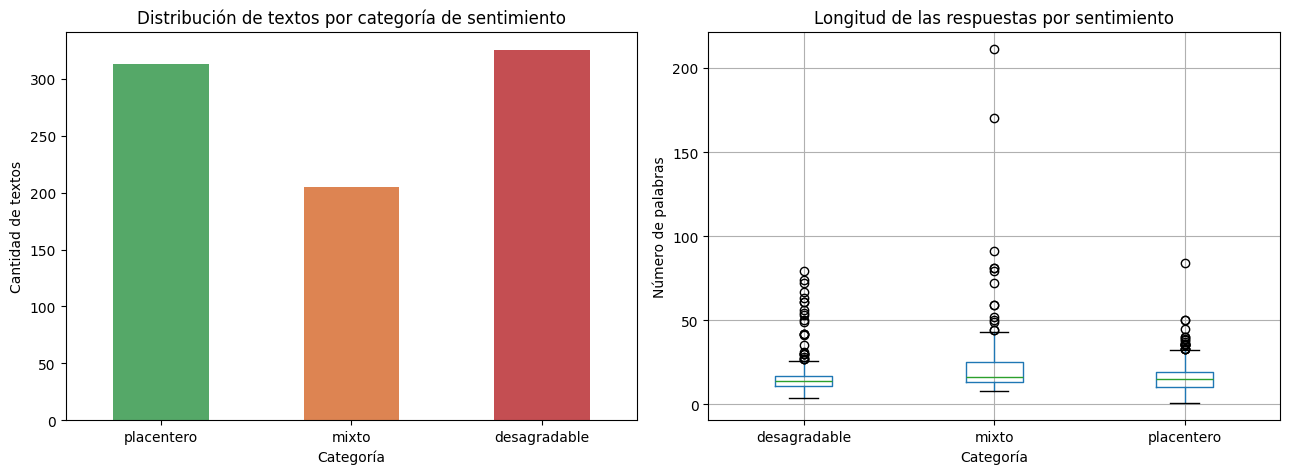

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_entrenamiento['etiqueta'].value_counts().reindex(
    ['placentero', 'mixto', 'desagradable']
).plot(kind='bar', ax=axes[0], color=['#55A868', '#DD8452', '#C44E52'])
axes[0].set_title('Distribución de textos por categoría de sentimiento')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Cantidad de textos')
axes[0].tick_params(axis='x', rotation=0)

df_entrenamiento.boxplot(column='num_palabras', by='etiqueta', ax=axes[1])
axes[1].set_title('Longitud de las respuestas por sentimiento')
plt.suptitle('')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Número de palabras')

plt.tight_layout()
plt.show()


## Distribución por encuestador

A diferencia de la versión anterior (un solo encuestador), ahora vale la pena
revisar si la mezcla de las 12 fuentes introduce algún sesgo evidente por
encuestador.

In [9]:
tabla_encuestador = df_completo.groupby(['encuestador', 'etiqueta']).size().unstack(fill_value=0)
orden_cols = [c for c in ['placentero', 'mixto', 'desagradable', 'revisar_manualmente'] if c in tabla_encuestador.columns]
tabla_encuestador = tabla_encuestador[orden_cols]
tabla_encuestador['total'] = tabla_encuestador.sum(axis=1)
tabla_encuestador.sort_values('total', ascending=False)


etiqueta,placentero,mixto,desagradable,revisar_manualmente,total
encuestador,,,,,
menco,17,75,108,0,200
jorge,54,23,15,7,99
eberto,24,16,40,0,80
elvis,33,6,34,7,80
marlon,31,14,7,18,70
abraham,16,29,20,3,68
edgar,20,7,20,17,64
jair,11,14,28,9,62
karen,13,9,27,13,62


## Calidad y validación del corpus

La calidad del corpus se revisó mediante los siguientes controles:

1. **Cantidad de archivos por categoría** -> verificado (ver tablas anteriores).
2. **Extensión .txt** -> todos los archivos generados usan `.txt`.
3. **Codificación UTF-8** -> se verificó explícitamente: los 830 archivos
   crudos de `data/bases_de_datos/` se leen sin error de codificación.
4. **Respuestas vacías** -> ninguno de los 830 archivos crudos está vacío; se
   filtra igualmente cualquier texto vacío tras el parseo por robustez.
5. **Respuestas duplicadas** -> se revisan a continuación.
6. **Longitud de las respuestas** -> analizada arriba.
7. **Distribución de categorías** -> mucho más balanceada que en la versión de
   un solo encuestador (ver reflexión).
8. **Correspondencia etiqueta-contenido** -> auditable vía columnas
   `evidencia_pos`/`evidencia_neg`.
9. **Casos ambiguos** -> 11% del corpus (107 de 965) no tiene evidencia léxica
   suficiente y se excluye del entrenamiento en vez de forzarle una etiqueta
   (`data/textos_revisar_manualmente.csv`).

In [10]:
duplicados = df_completo[df_completo.duplicated(subset='texto', keep=False)]
print("Respuestas duplicadas encontradas:", duplicados['texto'].nunique(), "grupos", f"({len(duplicados)} respuestas)")
print()
print("Duplicados por encuestador (top 5):")
print(duplicados['encuestador'].value_counts().head())


Respuestas duplicadas encontradas: 41 grupos (149 respuestas)

Duplicados por encuestador (top 5):
encuestador
eberto    80
menco     53
jorge     10
marlon     4
juan       2
Name: count, dtype: int64


El encuestador `eberto` concentra buena parte de estos duplicados: varios de sus
archivos (p. ej. cada 5 estudiantes) contienen exactamente el mismo texto, lo que
sugiere que pudo reutilizar un mismo formulario o respuesta de ejemplo para varios
estudiantes en su recolección. Siguiendo el mismo criterio que la versión anterior
de este proyecto (y el proyecto guía: *"No se modificará el texto original para
favorecer una determinada categoría"*), **no se eliminan** estos duplicados: son
parte real de los datos recolectados y se documentan aquí por transparencia, no se
ocultan ni se corrigen.

In [11]:
muestra_revisar = df_revisar[['encuestador', 'texto']].sample(8, random_state=1)
pd.set_option('display.max_colwidth', 100)
muestra_revisar


,encuestador,texto
67,karen,siento que el tiempo pasa muy lento en las clases de matematicas
35,jaime,"Cuando tengo varias materias con trabajos, la carga aumenta, pero generalmente logro organizarme."
73,karen,siento que memorizamos para el examen y despues se nos olvida todo
62,karen,ya en noveno uno se siente mas grande pero el tiempo libre se reduce mucho
39,jair,Normal me siento y en mi casa mejor.
53,juan,tenemos muy poquito tiempo
56,juan,dejan mucha tarea
88,marlon,Me parece excelento por que duro mas en mi casa que en el colegio y Por eso hacemos las tareas e...


## Reflexión de la Fase 0

**¿Por qué reconstruir el corpus con las 12 fuentes en vez de dejarlo como estaba?**
La versión anterior de este proyecto, sin darse cuenta, solo usaba los datos de
**un** encuestador (menco) de los 12 disponibles: el Excel original agrupaba
"pregunta 1" y "pregunta 2" en 2 celdas, y esas 2 celdas resultaron ser,
exactamente, las respuestas de `encuesta_menco`. Además, esa construcción tenía un
error real: dos respuestas quedaron fusionadas en una sola porque a un archivo le
faltó un salto de línea al copiarlo al Excel (199 respuestas en vez de 200). Leer
directamente los `.txt` crudos de los 12 encuestadores no solo amplía el corpus
4.3x (965 vs. 199 respuestas individuales): también elimina ese tipo de error de
raíz, porque ya no depende de un paso manual de copiado a Excel.

**¿Por qué 3 categorías de sentimiento y no una clasificación binaria?**
El proyecto guía usado como referencia trabajó con una clasificación binaria
(positivo/negativo). Aquí se optó por las 3 categorías pedidas en la asignación
(mínimo 3), agregando "mixto" como categoría explícita, porque un patrón MUY
frecuente en las respuestas es la estructura *"me gusta la escuela, **pero**
..."*: forzar esas respuestas a "positivo" o "negativo" perdería información
real. La categoría "mixto" resultó tener más del doble de textos que en la
versión anterior (205 vs. 68), lo que confirma que sigue siendo necesaria a
esta escala.

**¿Qué desafío principal tuvo la Fase 0 esta vez?**
Dos, en este orden: (1) **normalizar 5 formatos de archivo distintos** entre los
12 encuestadores sin perder ni mezclar mal ninguna respuesta —se validó cada
patrón contra el 100% de los archivos de su carpeta, no solo una muestra—, y
(2) **recalibrar el lexicón** para que siguiera siendo confiable con 12 estilos de
escritura distintos en vez de uno solo, sin introducir falsos positivos nuevos
al ampliar el vocabulario (se verificó explícitamente que ningún texto cambiara
de polaridad de forma incorrecta al pasar de una versión del lexicón a la
siguiente).

**¿Qué se observa en la distribución de categorías?**
El corpus ampliado quedó notablemente más balanceado que la versión de un solo
encuestador: 39% desagradable / 37% placentero / 24% mixto (antes: 56% / 9% /
35%). Esto sugiere que el fuerte sesgo hacia "desagradable" de la versión
anterior era, al menos en parte, un artefacto de usar los datos de un único
encuestador (cuyo grupo de estudiantes pudo tener una experiencia más negativa
en promedio, o cuyas preguntas motivaron respuestas más críticas) y no una
característica general de cómo los estudiantes perciben el tiempo escolar.